# Notebook to plot results from a `tdinf` run

In [1]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
warnings.filterwarnings("ignore", "UserWarning")

import numpy as np 
import scipy.linalg as sl

# for plotting
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from matplotlib.lines import Line2D
import seaborn as sns
sns.set_palette('colorblind')

from tdinf import group_postprocess, utils, run_sampler, waveform_h5s

### Load in result

Results from `tdinf` runs can easily be loaded in using the `group_postprocess` module:

In [2]:
# Load in the result
result = group_postprocess.load_run_settings_from_directory('SEO/output')

XLAL Error - XLALSimInspiralDecomposeWaveformString (LALSimInspiral.c:4204): Invalid waveform string `SEOBNRv5PHM'.
XLAL Error - XLALSimInspiralDecomposeWaveformString (LALSimInspiral.c:4204): Invalid waveform string `SEOBNRv5PHM'.
XLAL Error - XLALSimInspiralDecomposeWaveformString (LALSimInspiral.c:4204): Invalid waveform string `SEOBNRv5PHM'.
XLAL Error - XLALSimInspiralDecomposeWaveformString (LALSimInspiral.c:4204): Invalid waveform string `SEOBNRv5PHM'.
XLAL Error - XLALSimInspiralDecomposeWaveformString (LALSimInspiral.c:4204): Invalid waveform string `SEOBNRv5PHM'.
XLAL Error - XLALSimInspiralDecomposeWaveformString (LALSimInspiral.c:4204): Invalid waveform string `SEOBNRv5PHM'.
XLAL Error - XLALSimInspiralDecomposeWaveformString (LALSimInspiral.c:4204): Invalid waveform string `SEOBNRv5PHM'.
XLAL Error - XLALSimInspiralDecomposeWaveformString (LALSimInspiral.c:4204): Invalid waveform string `SEOBNRv5PHM'.
XLAL Error - XLALSimInspiralDecomposeWaveformString (LALSimInspiral.c:42

The result object has helpful keys:
- `dir` tells you the directory where the output lives, relative to this notebook
- `runs` has `args`, `kwargs` and the `likelihood_manager` for the run corresponding to each cutoff time (including `full`)
- `dfs` has `pandas` `DataFrame`s containing the posterior samples for the run for each cutoff time

In [3]:
# Extract the likelihood_manager for easy use
lm = result['runs']['full']['likelihood_manager']

The different runs are labeled as follows: 
- full data: `full`
- pre cutoff: `pre_XX`
- post cutoff: `post_XX`
This can be seen by printing out the keys to `result['dfs']`:

In [4]:
result['dfs'].keys()

dict_keys(['pre_0.0', 'pre_-0.5', 'post_-0.5', 'post_-1.0', 'post_0.0', 'full', 'pre_-1.0'])

### Plot posterior distributions for the full run and pre/post cutoff times

Let's plot posterior distributions for each of the 15 binary black hole parameters:

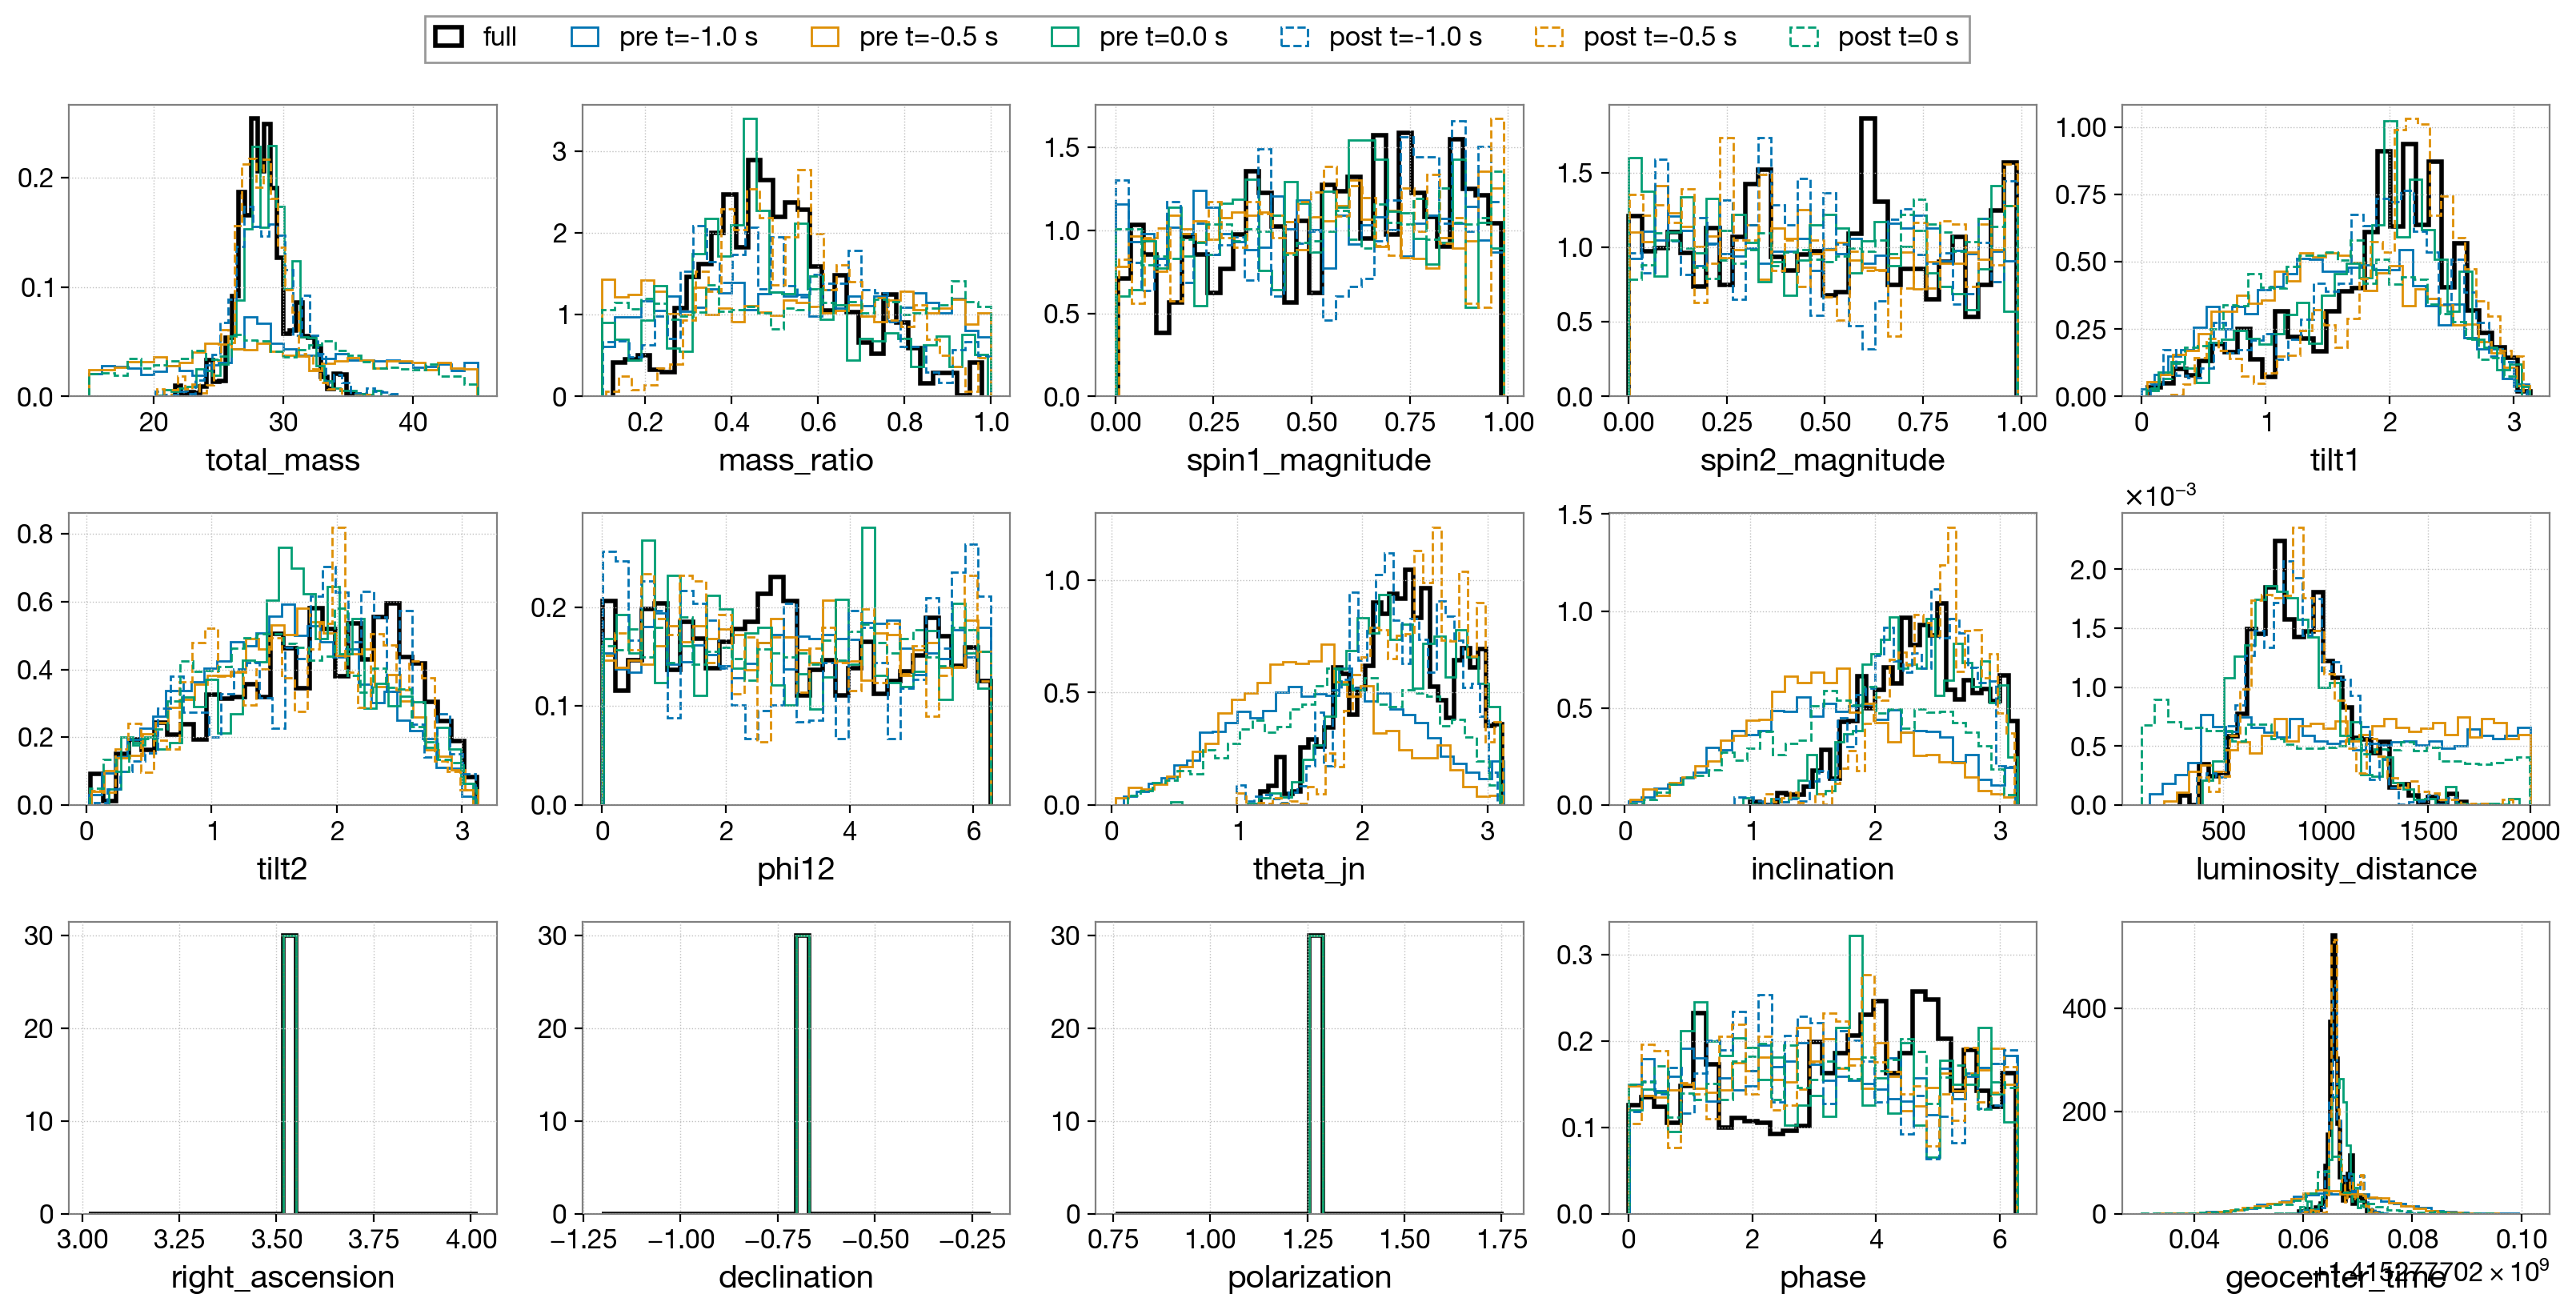

In [5]:
params_to_plot = ['total_mass', 'mass_ratio', 'spin1_magnitude', 'spin2_magnitude',
           'tilt1', 'tilt2', 'phi12', 'theta_jn', 'inclination','luminosity_distance',  
                  'right_ascension', 'declination', 'polarization', 'phase', 'geocenter_time']

fig, axes = plt.subplots(3,5,figsize=(20,9))

for ax, p in zip(axes.flatten(), params_to_plot):
    
    hist_kws = dict(density=True, histtype='step', bins=30) 

    ax.hist(result['dfs']['full'][p], **hist_kws, lw=2, color='k', label='full')

    ax.hist(result['dfs']['pre_-1.0'][p], **hist_kws, label='pre t=-1.0 s', color='C0')
    ax.hist(result['dfs']['pre_-0.5'][p], **hist_kws, label='pre t=-0.5 s', color='C1')
    ax.hist(result['dfs']['pre_0.0'][p], **hist_kws, label='pre t=0.0 s', color='C2')
    
    ax.hist(result['dfs']['post_-1.0'][p], **hist_kws, label='post t=-1.0 s', color='C0', ls='--')
    ax.hist(result['dfs']['post_-0.5'][p], **hist_kws, label='post t=-0.5 s', color='C1', ls='--')
    ax.hist(result['dfs']['post_0.0'][p], **hist_kws, label='post t=0 s', color='C2', ls='--')
    
    ax.set_xlabel(p)
    ax.grid(color='silver', ls=':')

axes[0][0].legend(ncols=7, loc='lower left', bbox_to_anchor=(0.8,1.1))
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.show()

From these we are see at what cutoff times information about various parameters is gained or lost. For example, we constrain but slightly under-estimate the total mass for the `pre_0.05` run, while we over-estimate it for `post_-0.05` and `post_0.0`. For other cutoffs, we return the prior, meaning there is not information about total mass looking at, e.g., just the `post_0.05` data.

### Plot strain and waveform reconstructions

For easy visualization, let's generate the whitened strain. We can easily whiten data using the `utils` module. 

In [6]:
# Get whitened strain 
data_dict_wh =  utils.whitenData_dict_TD(lm.data_dict, lm)

Next, load in the waveform reconstructions for these runs with the `waveform_h5s` module, and again whiten them.

In [7]:
# Load waveform reconstructions from the full run
wfs_full = waveform_h5s.load_waveform_h5py(f'SEO/output/waveforms/full_waveforms.h5')

# Load waveform reconstructions post t=0 only
wfs_rd = waveform_h5s.load_waveform_h5py(f'SEO/output/waveforms/post_0.0_waveforms.h5')

wfs_0 = waveform_h5s.load_waveform_h5py(f'SEO/output/waveforms/pre_0.0_waveforms.h5')
wfs_1 = waveform_h5s.load_waveform_h5py(f'SEO/output/waveforms/pre_-1.0_waveforms.h5')
wfs_5 = waveform_h5s.load_waveform_h5py(f'SEO/output/waveforms/pre_-0.5_waveforms.h5')

In [8]:
# # Load waveform reconstructions from the full run
# wfs_full = waveform_h5s.load_waveform_h5py(f'output/waveforms/full_waveforms.h5')

# # Load waveform reconstructions post t=0 only
# # wfs_rd = waveform_h5s.load_waveform_h5py(f'output/waveforms/post_0.0_waveforms.h5')
# wfs_rd = waveform_h5s.load_waveform_h5py(f'output/waveforms/pre_0.05_waveforms.h5')
# wfs_pre_n = waveform_h5s.load_waveform_h5py(f'output/waveforms/pre_-0.05_waveforms.h5')
# wfs_pre_z = waveform_h5s.load_waveform_h5py(f'output/waveforms/pre_0.0_waveforms.h5')

In [9]:
# Whiten waveform reconstructions
L_dict= {} # first, make a Cholesky decomposition of the Toeplitz matrix from the ACF for quick whitening
for ifo in lm.ifos:
    C = sl.toeplitz(lm.rho_dict[ifo])
    L_dict[ifo] = sl.cholesky(C,lower=True)
    
wfs_full_whitened = utils.whiten_wfs_TD(wfs_full['samples'], L_dict)
wfs_rd_whitened = utils.whiten_wfs_TD(wfs_rd['samples'], L_dict)
wfs_0_whitened = utils.whiten_wfs_TD(wfs_0['samples'], L_dict)
wfs_1_whitened = utils.whiten_wfs_TD(wfs_1['samples'], L_dict)
wfs_5_whitened = utils.whiten_wfs_TD(wfs_1['samples'], L_dict)
# wfs_pre_n_whitened = utils.whiten_wfs_TD(wfs_pre_n['samples'], L_dict)
# wfs_pre_z_whitened = utils.whiten_wfs_TD(wfs_pre_z['samples'], L_dict)

100%|█████████████████████████████████████████████████████████████| 1000/1000 [00:15<00:00, 64.37it/s]


To plot our reconstructions as a function of time from merger, we also need the delay times for each detector. These can be generated using the `likelihood_manager` and the reference time and sky position for our run.

In [10]:
# Get detector delay times 
dt_dict = lm.waveform_manager.antenna_and_time_manager.compute_time_delay_dict(
    result['runs']['full']['kwargs']['right_ascension'], 
    result['runs']['full']['kwargs']['declination'], 
    lm.reference_time, 
    lm.ifos
)

Plot full reconstructions:

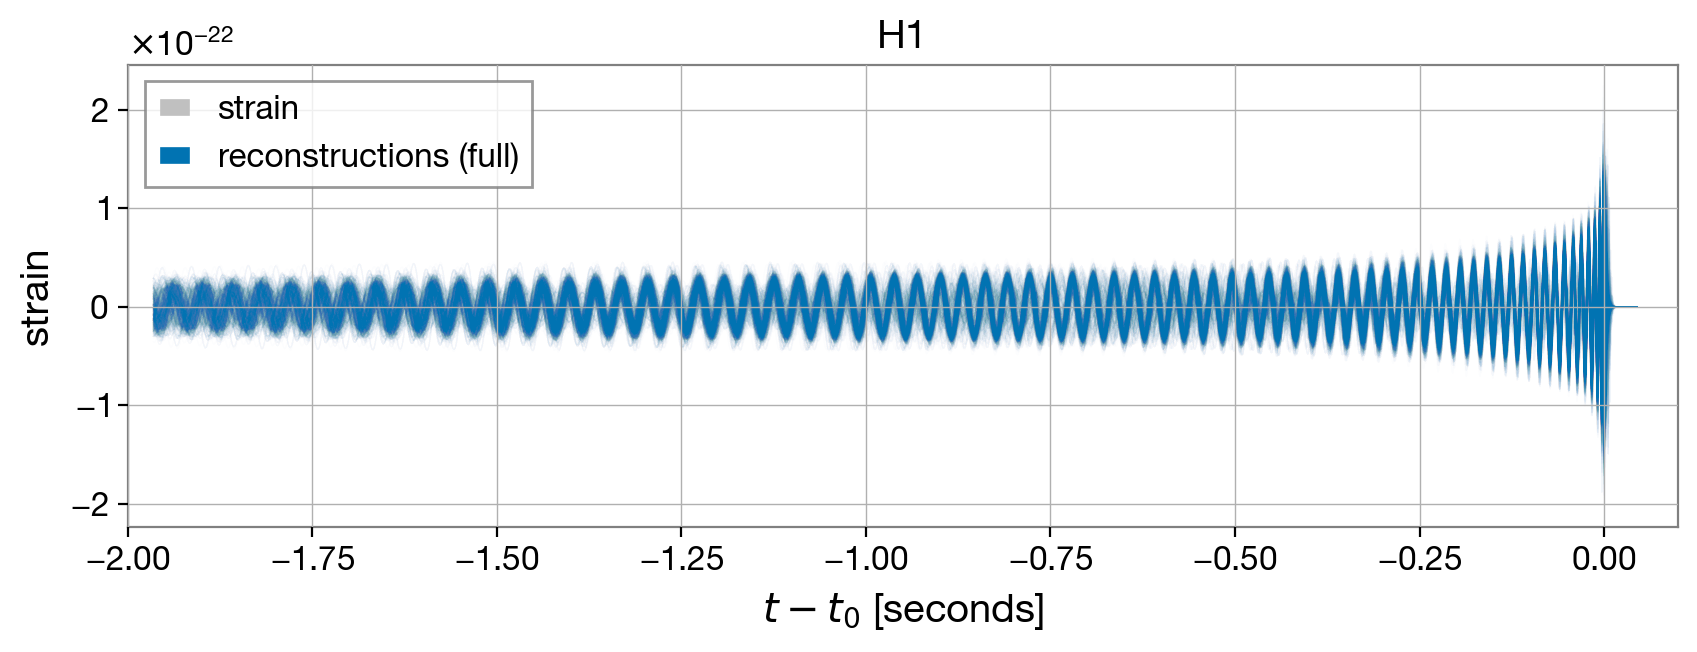

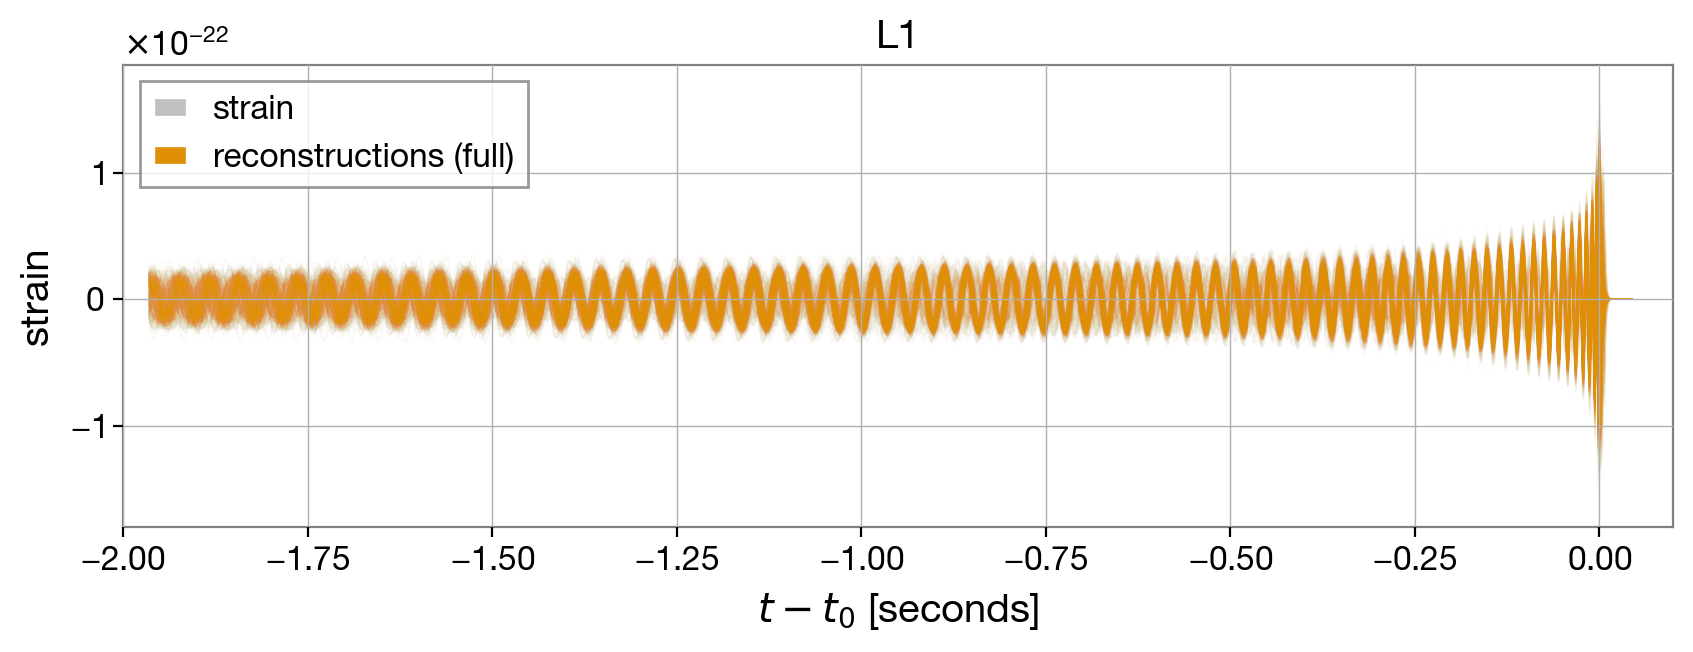

In [11]:
for i, ifo in enumerate(lm.ifos): 

    plt.figure(figsize=(10, 3))

    time_from_merger = lm.time_dict[ifo] - lm.reference_time - dt_dict[ifo]
    
    # plt.plot(time_from_merger, data_dict_wh[ifo], color='silver', zorder=0)
    
    for j in range(len(wfs_full['samples'])):
        plt.plot(time_from_merger, wfs_full['samples'][j][ifo], color=f'C{i}', lw=0.5, alpha=0.01, zorder=2)

    plt.title(ifo)
    handles = [Line2D([], [], color='silver', label='strain'), Line2D([], [], color=f'C{i}', label='reconstructions (full)')]
    plt.legend(handles=handles)
    plt.xlim(-2, 0.1)
    plt.xlabel('$t-t_0$ [seconds]')
    plt.ylabel('strain')
    plt.show()

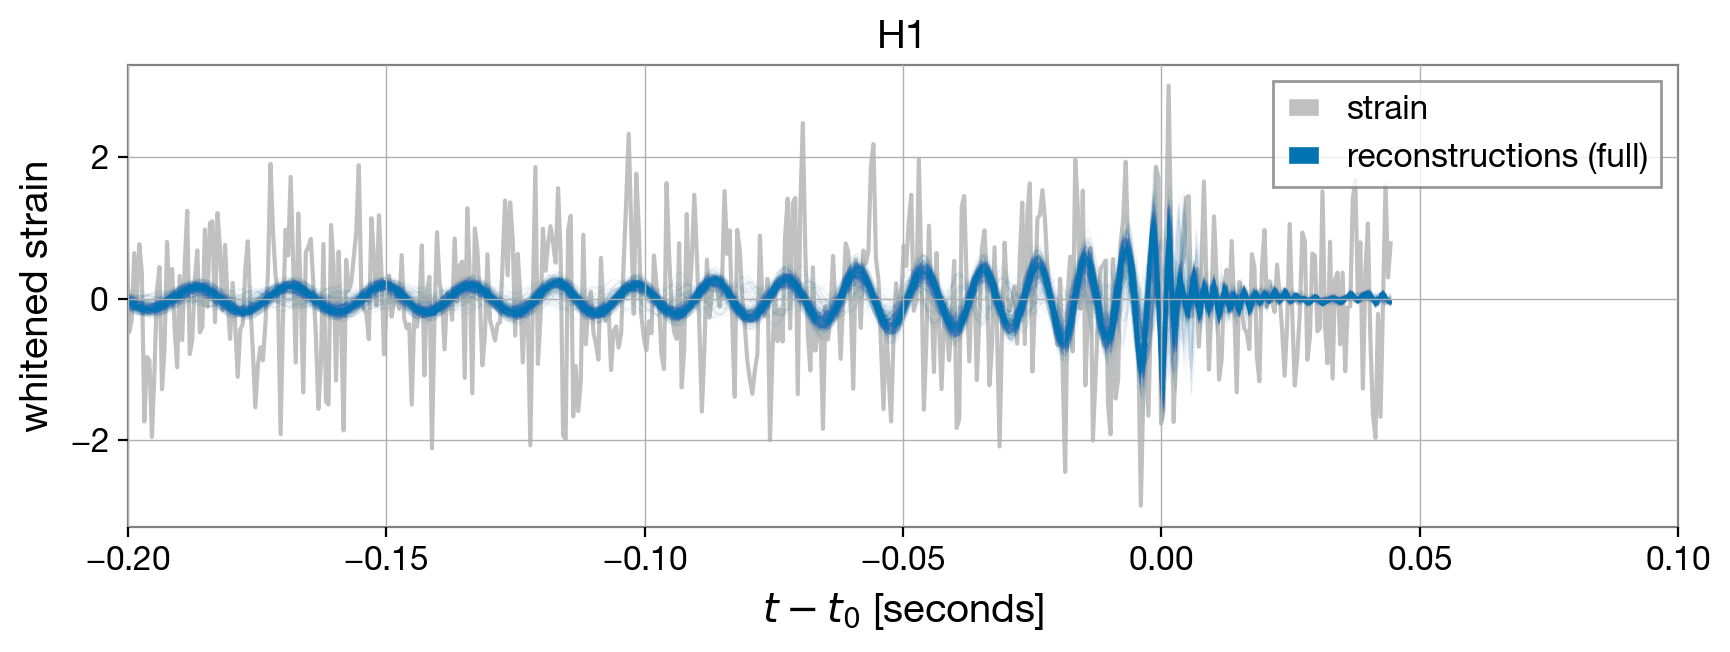

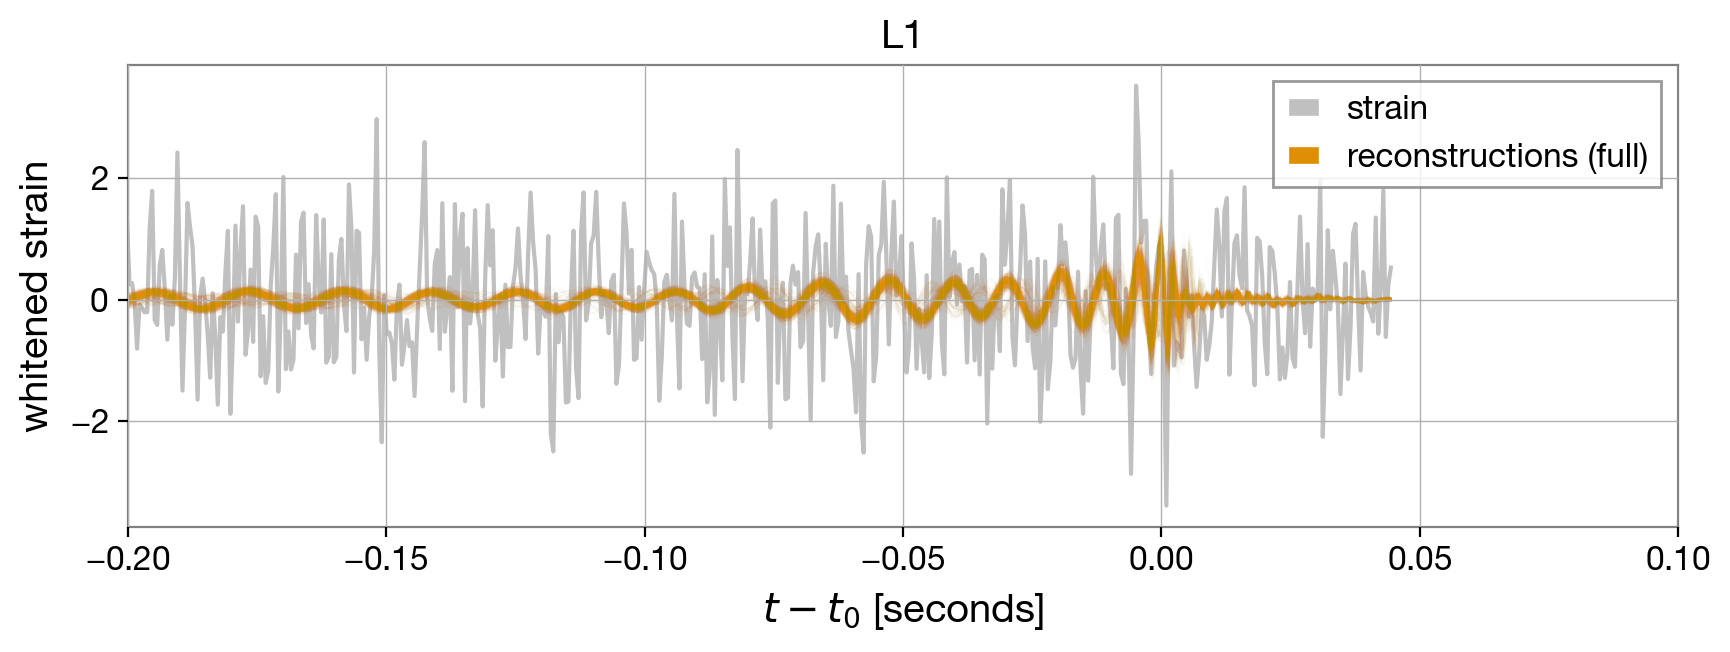

In [39]:
for i, ifo in enumerate(lm.ifos): 

    plt.figure(figsize=(10, 3))

    time_from_merger = lm.time_dict[ifo] - lm.reference_time - dt_dict[ifo]
    
    plt.plot(time_from_merger, data_dict_wh[ifo], color='silver', zorder=0)
    
    for j in range(len(wfs_full['samples'])):
        plt.plot(time_from_merger, wfs_full_whitened[j][ifo], color=f'C{i}', lw=0.5, alpha=0.01, zorder=2)

    plt.title(ifo)
    handles = [Line2D([], [], color='silver', label='strain'), Line2D([], [], color=f'C{i}', label='reconstructions (full)')]
    plt.legend(handles=handles)
    plt.xlim(-0.2, 0.1)
    plt.xlabel('$t-t_0$ [seconds]')
    plt.ylabel('whitened strain')
    plt.show()

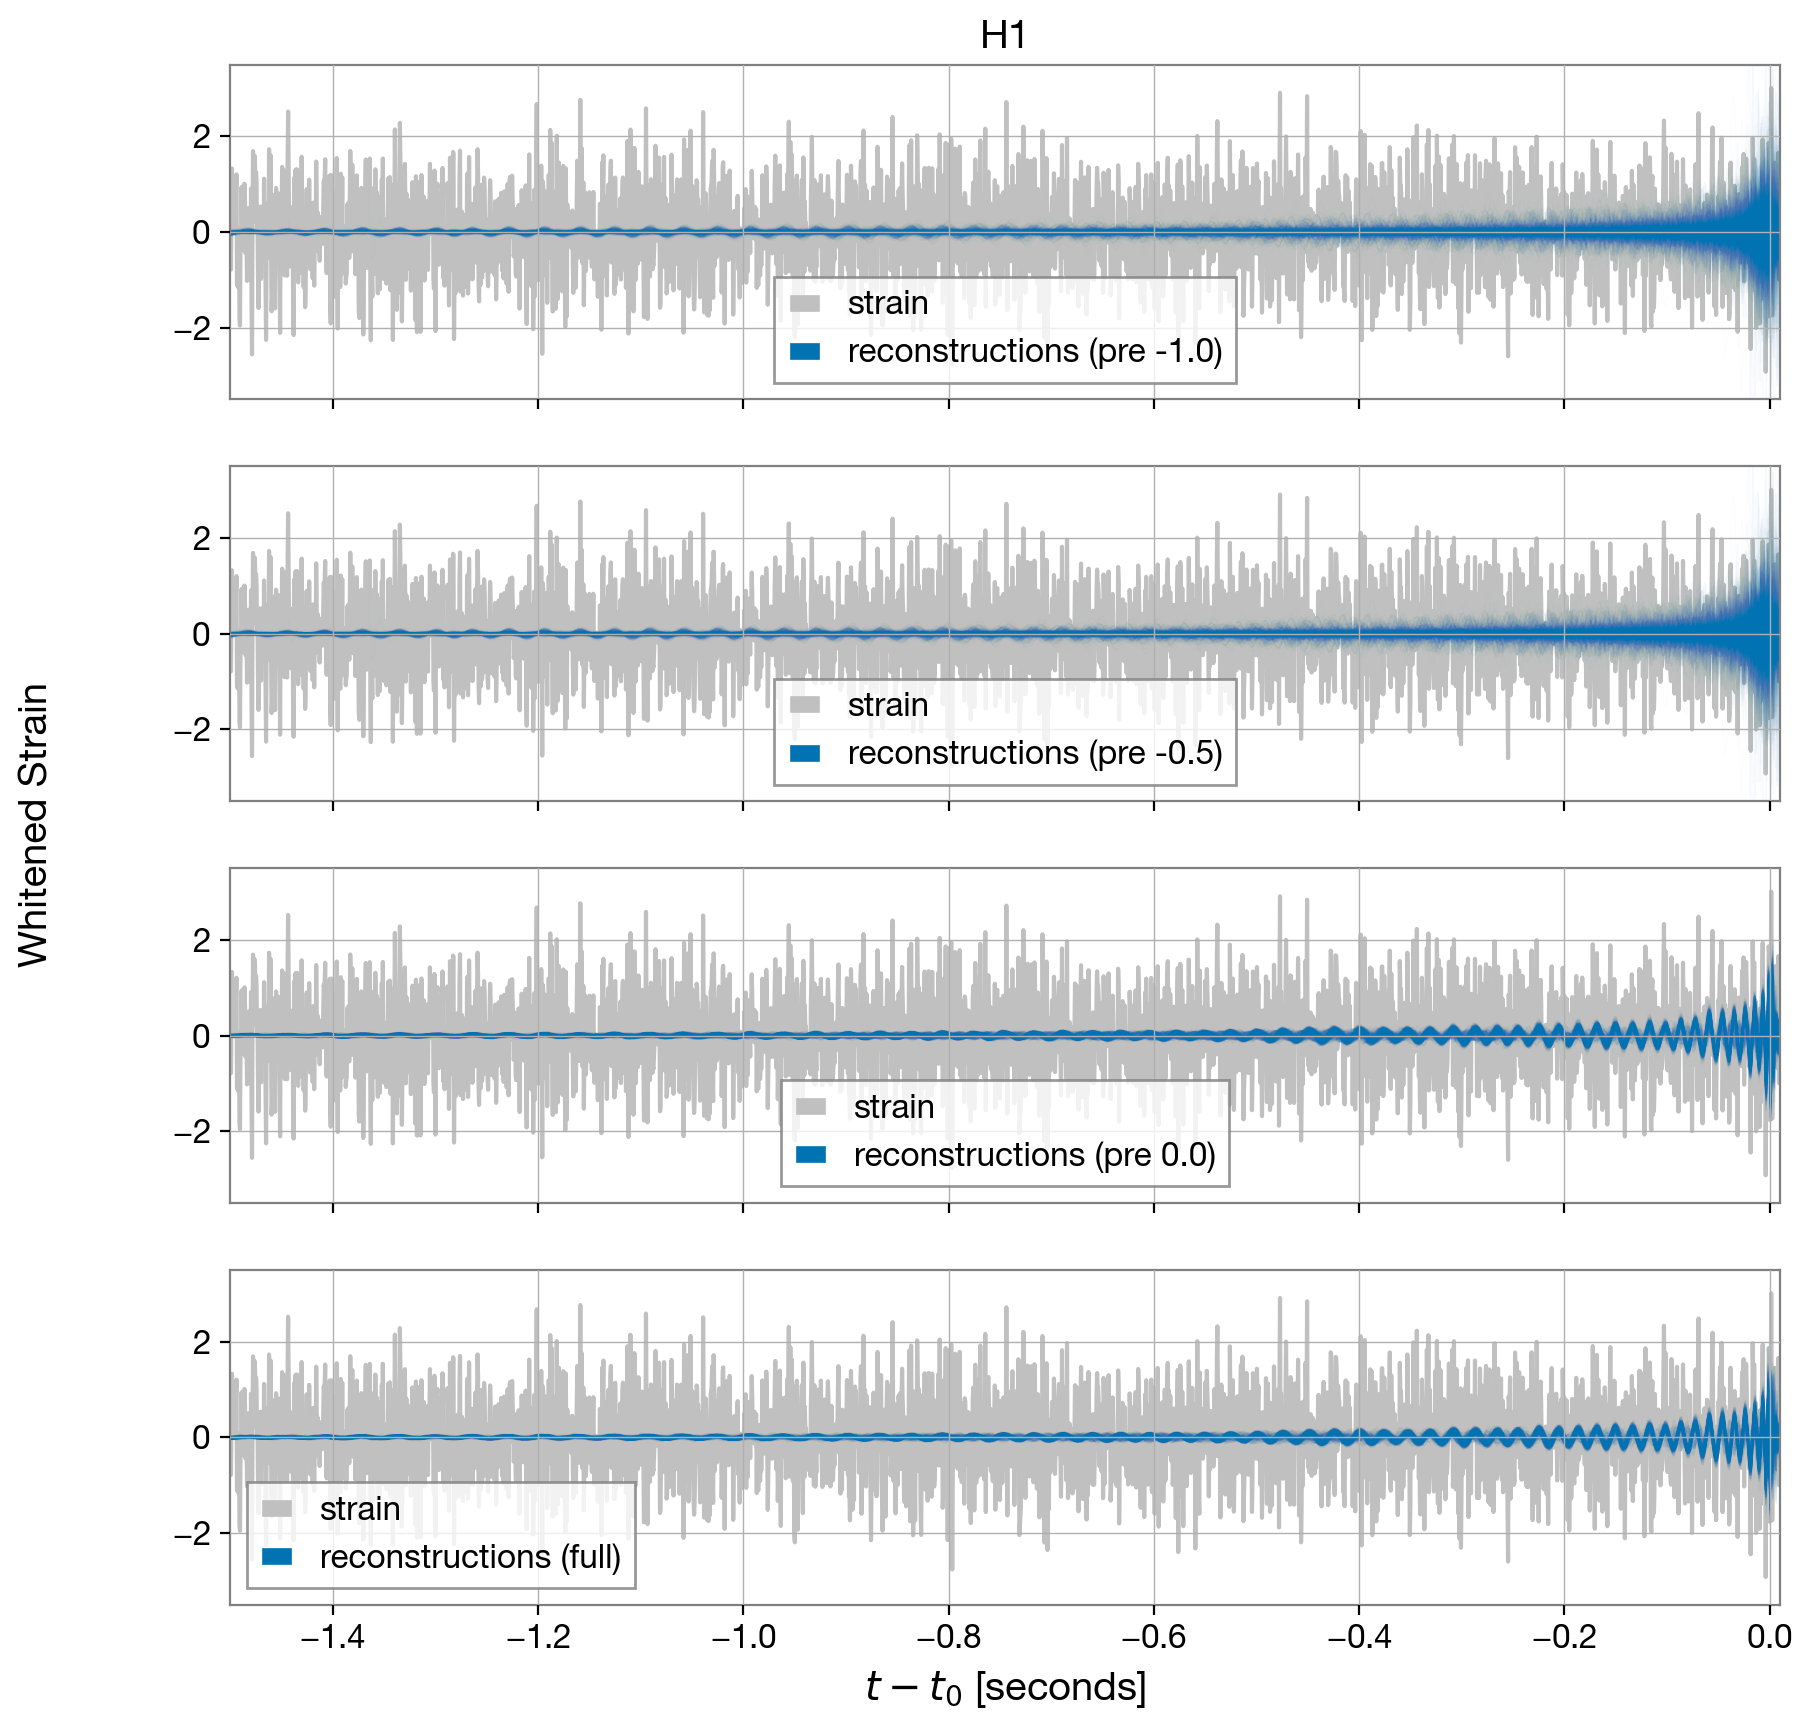

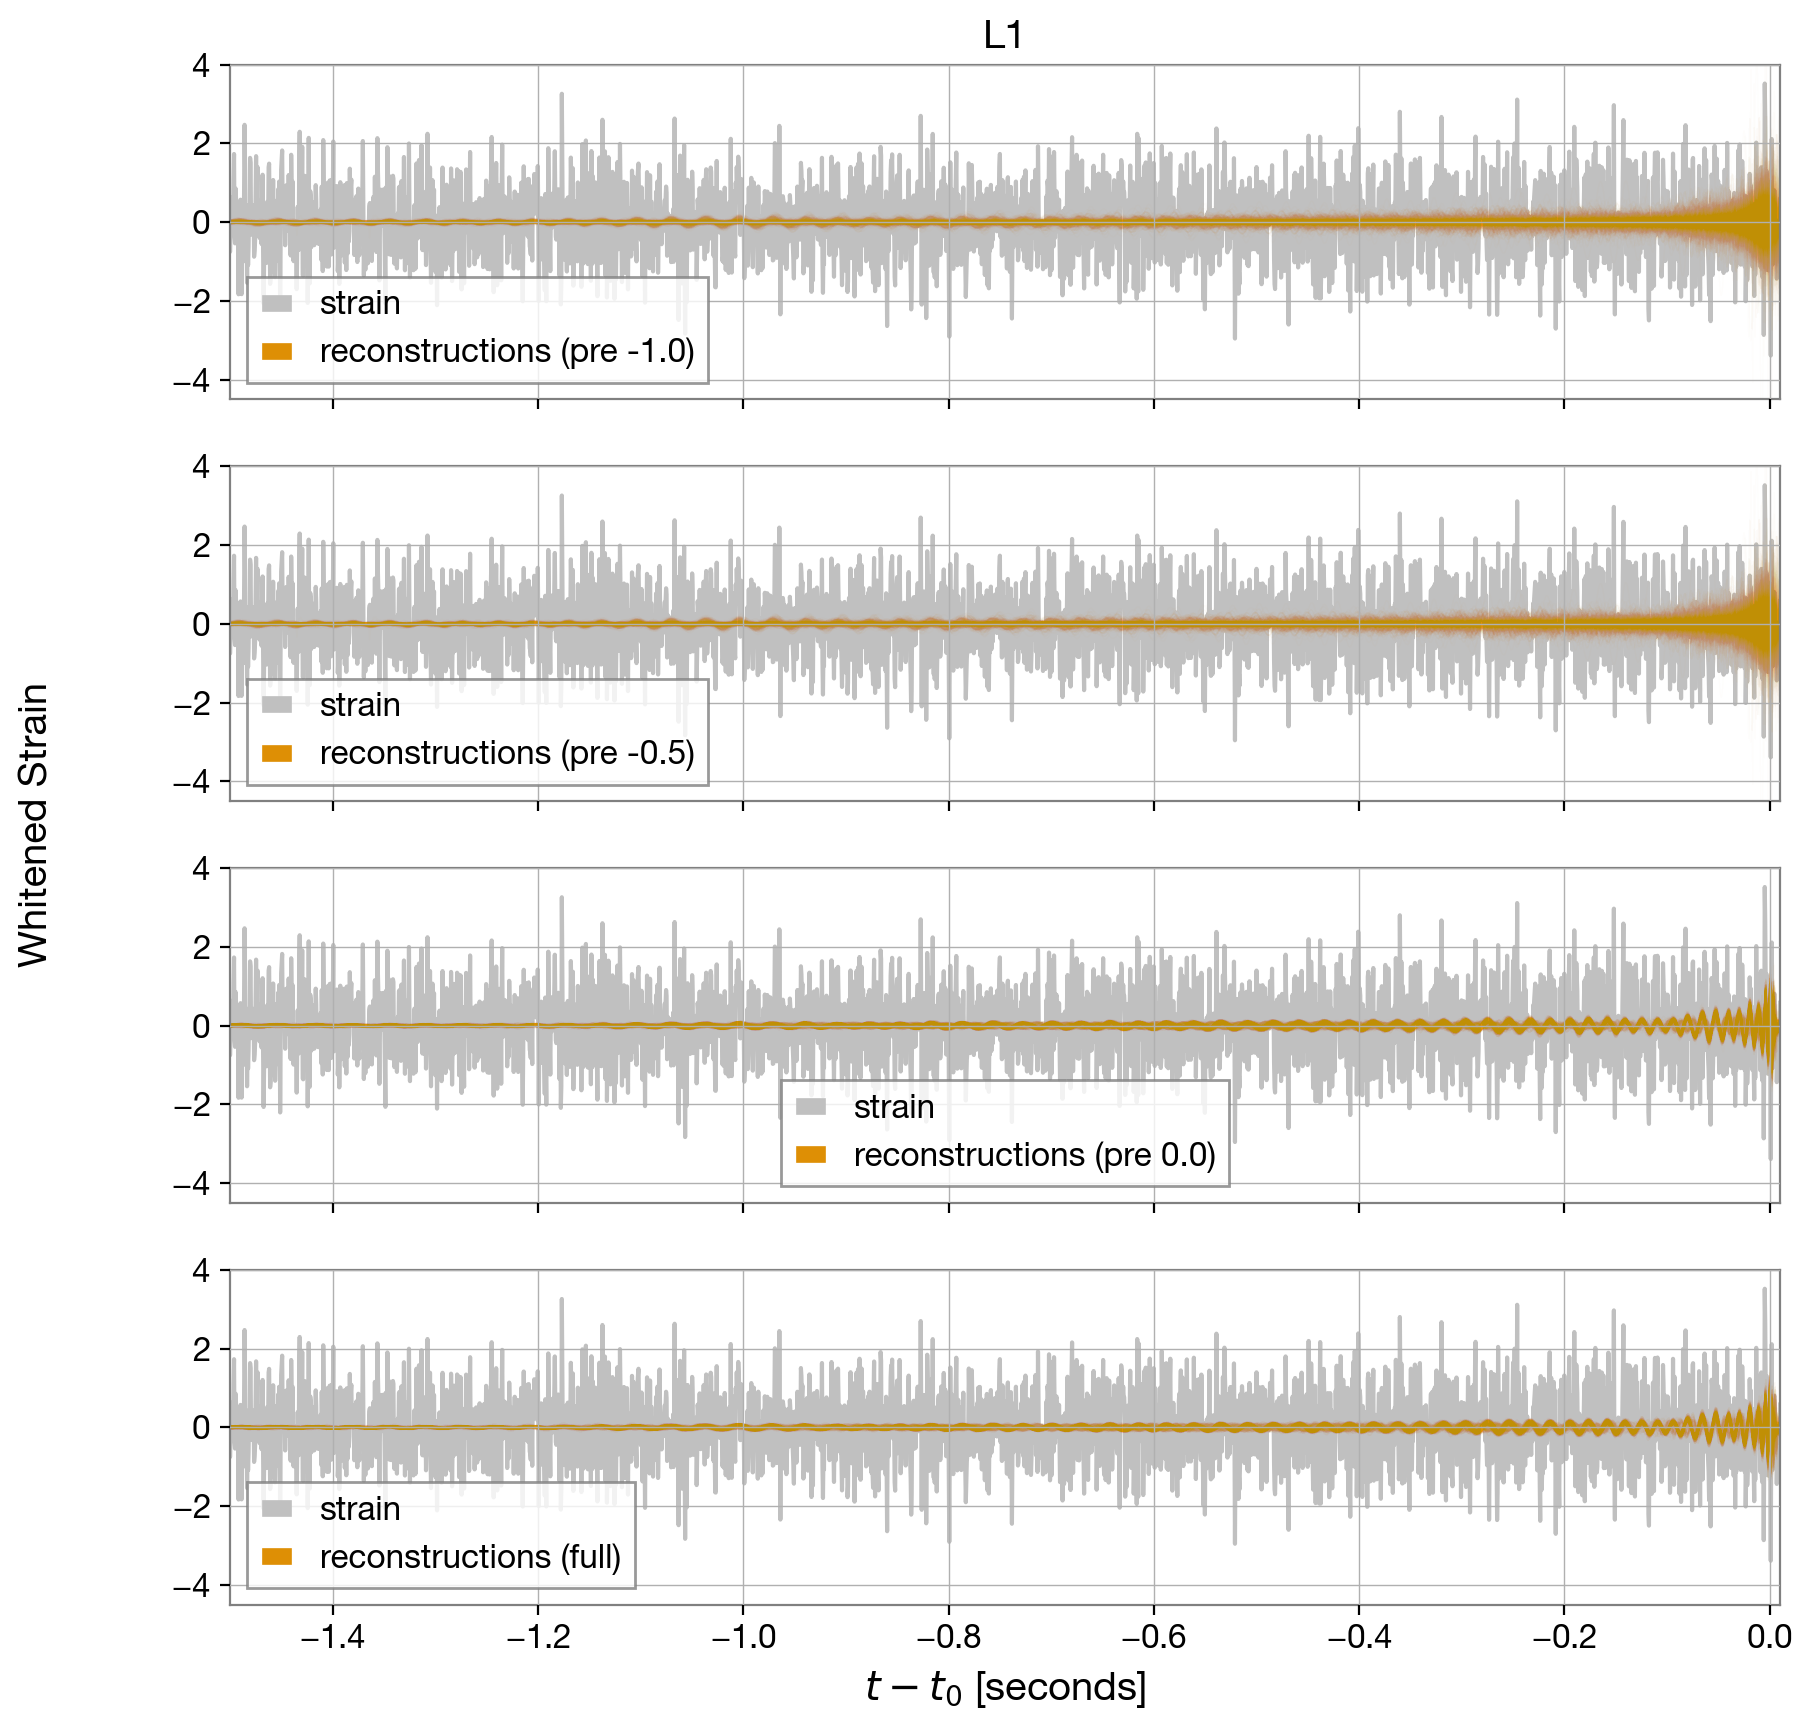

In [18]:
for i, ifo in enumerate(lm.ifos): 

    fig, axes = plt.subplots(4, 1, sharey=True, sharex=True, figsize=(10, 10))

    time_from_merger = lm.time_dict[ifo] - lm.reference_time - dt_dict[ifo]

    ylim_dict = {'H1': (-3.5, 3.5), 'L1': (-4.5, 4)}
    
    axes[0].set_title(ifo)
    axes[0].plot(time_from_merger, data_dict_wh[ifo], color='silver', zorder=0)
    for j in range(len(wfs_1_whitened)):
        axes[0].plot(time_from_merger, wfs_1_whitened[j][ifo], color=f'C{i}', lw=0.5, alpha=0.01, zorder=2)
    handles = [Line2D([], [], color='silver', label='strain'), Line2D([], [], color=f'C{i}', label='reconstructions (pre -1.0)')]
    axes[0].legend(handles=handles)
    axes[0].set_xlim(-1.5, 0.01)
    axes[0].set_ylim(ylim_dict[ifo])

    axes[2].plot(time_from_merger, data_dict_wh[ifo], color='silver', zorder=0)
    for j in range(len(wfs_0_whitened)):
        axes[2].plot(time_from_merger, wfs_0_whitened[j][ifo], color=f'C{i}', lw=0.5, alpha=0.01, zorder=2)
    handles = [Line2D([], [], color='silver', label='strain'), Line2D([], [], color=f'C{i}', label='reconstructions (pre 0.0)')]
    axes[2].legend(handles=handles)    
    axes[2].set_xlim(-1.5, 0.01)
    axes[2].set_ylim(ylim_dict[ifo])
    
    axes[3].plot(time_from_merger, data_dict_wh[ifo], color='silver', zorder=0)
    for j in range(len(wfs_full_whitened)):
        axes[3].plot(time_from_merger, wfs_full_whitened[j][ifo], color=f'C{i}', lw=0.5, alpha=0.01, zorder=2)
    handles = [Line2D([], [], color='silver', label='strain'), Line2D([], [], color=f'C{i}', label='reconstructions (full)')]
    axes[3].legend(handles=handles)
    axes[3].set_xlim(-1.5, 0.01)
    axes[3].set_ylim(ylim_dict[ifo])

    axes[1].plot(time_from_merger, data_dict_wh[ifo], color='silver', zorder=0)
    for j in range(len(wfs_5_whitened)):
        axes[1].plot(time_from_merger, wfs_5_whitened[j][ifo], color=f'C{i}', lw=0.5, alpha=0.01, zorder=2)
    handles = [Line2D([], [], color='silver', label='strain'), Line2D([], [], color=f'C{i}', label='reconstructions (pre -0.5)')]
    axes[1].legend(handles=handles)
    axes[1].set_xlim(-1.5, 0.01)
    axes[1].set_ylim(ylim_dict[ifo])

    plt.xlabel('$t-t_0$ [seconds]')
    fig.supylabel('Whitened Strain')
    plt.show()

In [21]:
import numpy as np

with open("SEO/output/full_0.0seconds/full_0.0seconds.dat") as f:
    header = f.readline()
    print(header)

params = [
    "total_mass",
    "mass_ratio",
    "spin1_magnitude",
    "spin2_magnitude",
    "inclination",
    "luminosity_distance",
    "chi_effective"]

with open("SEO/output/full_0.0seconds/full_0.0seconds.dat") as f:
          header = f.readline().split()

cols = [header.index(p) for p in params]

data = np.loadtxt(
    "full_0.0seconds.dat",
    skiprows=1,
    unpack=True,
    usecols=cols
    )

right_ascension declination polarization total_mass mass_ratio luminosity_distance inclination spin1_magnitude spin2_magnitude phase spin1_x spin1_y spin1_z spin2_x spin2_y spin2_z geocenter_time theta_jn phi_jl tilt1 tilt2 phi12 ln_posterior ln_prior ln_likelihood



ValueError: 'chi_effective' is not in list

In [22]:
total_mass, mass_ratio, luminosity_distance, inclination, spin1_magnitude, spin2_magnitude = np.loadtxt("SEO/output/full_0.0seconds/full_0.0seconds.dat", skiprows=1, unpack=True, usecols=(3, 4, 5, 6, 7, 8))

In [24]:
params = ["total_mass", "mass_ratio", "luminosity_distance", "inclination", "spin1_magnitude", "spin2_magnitude"]

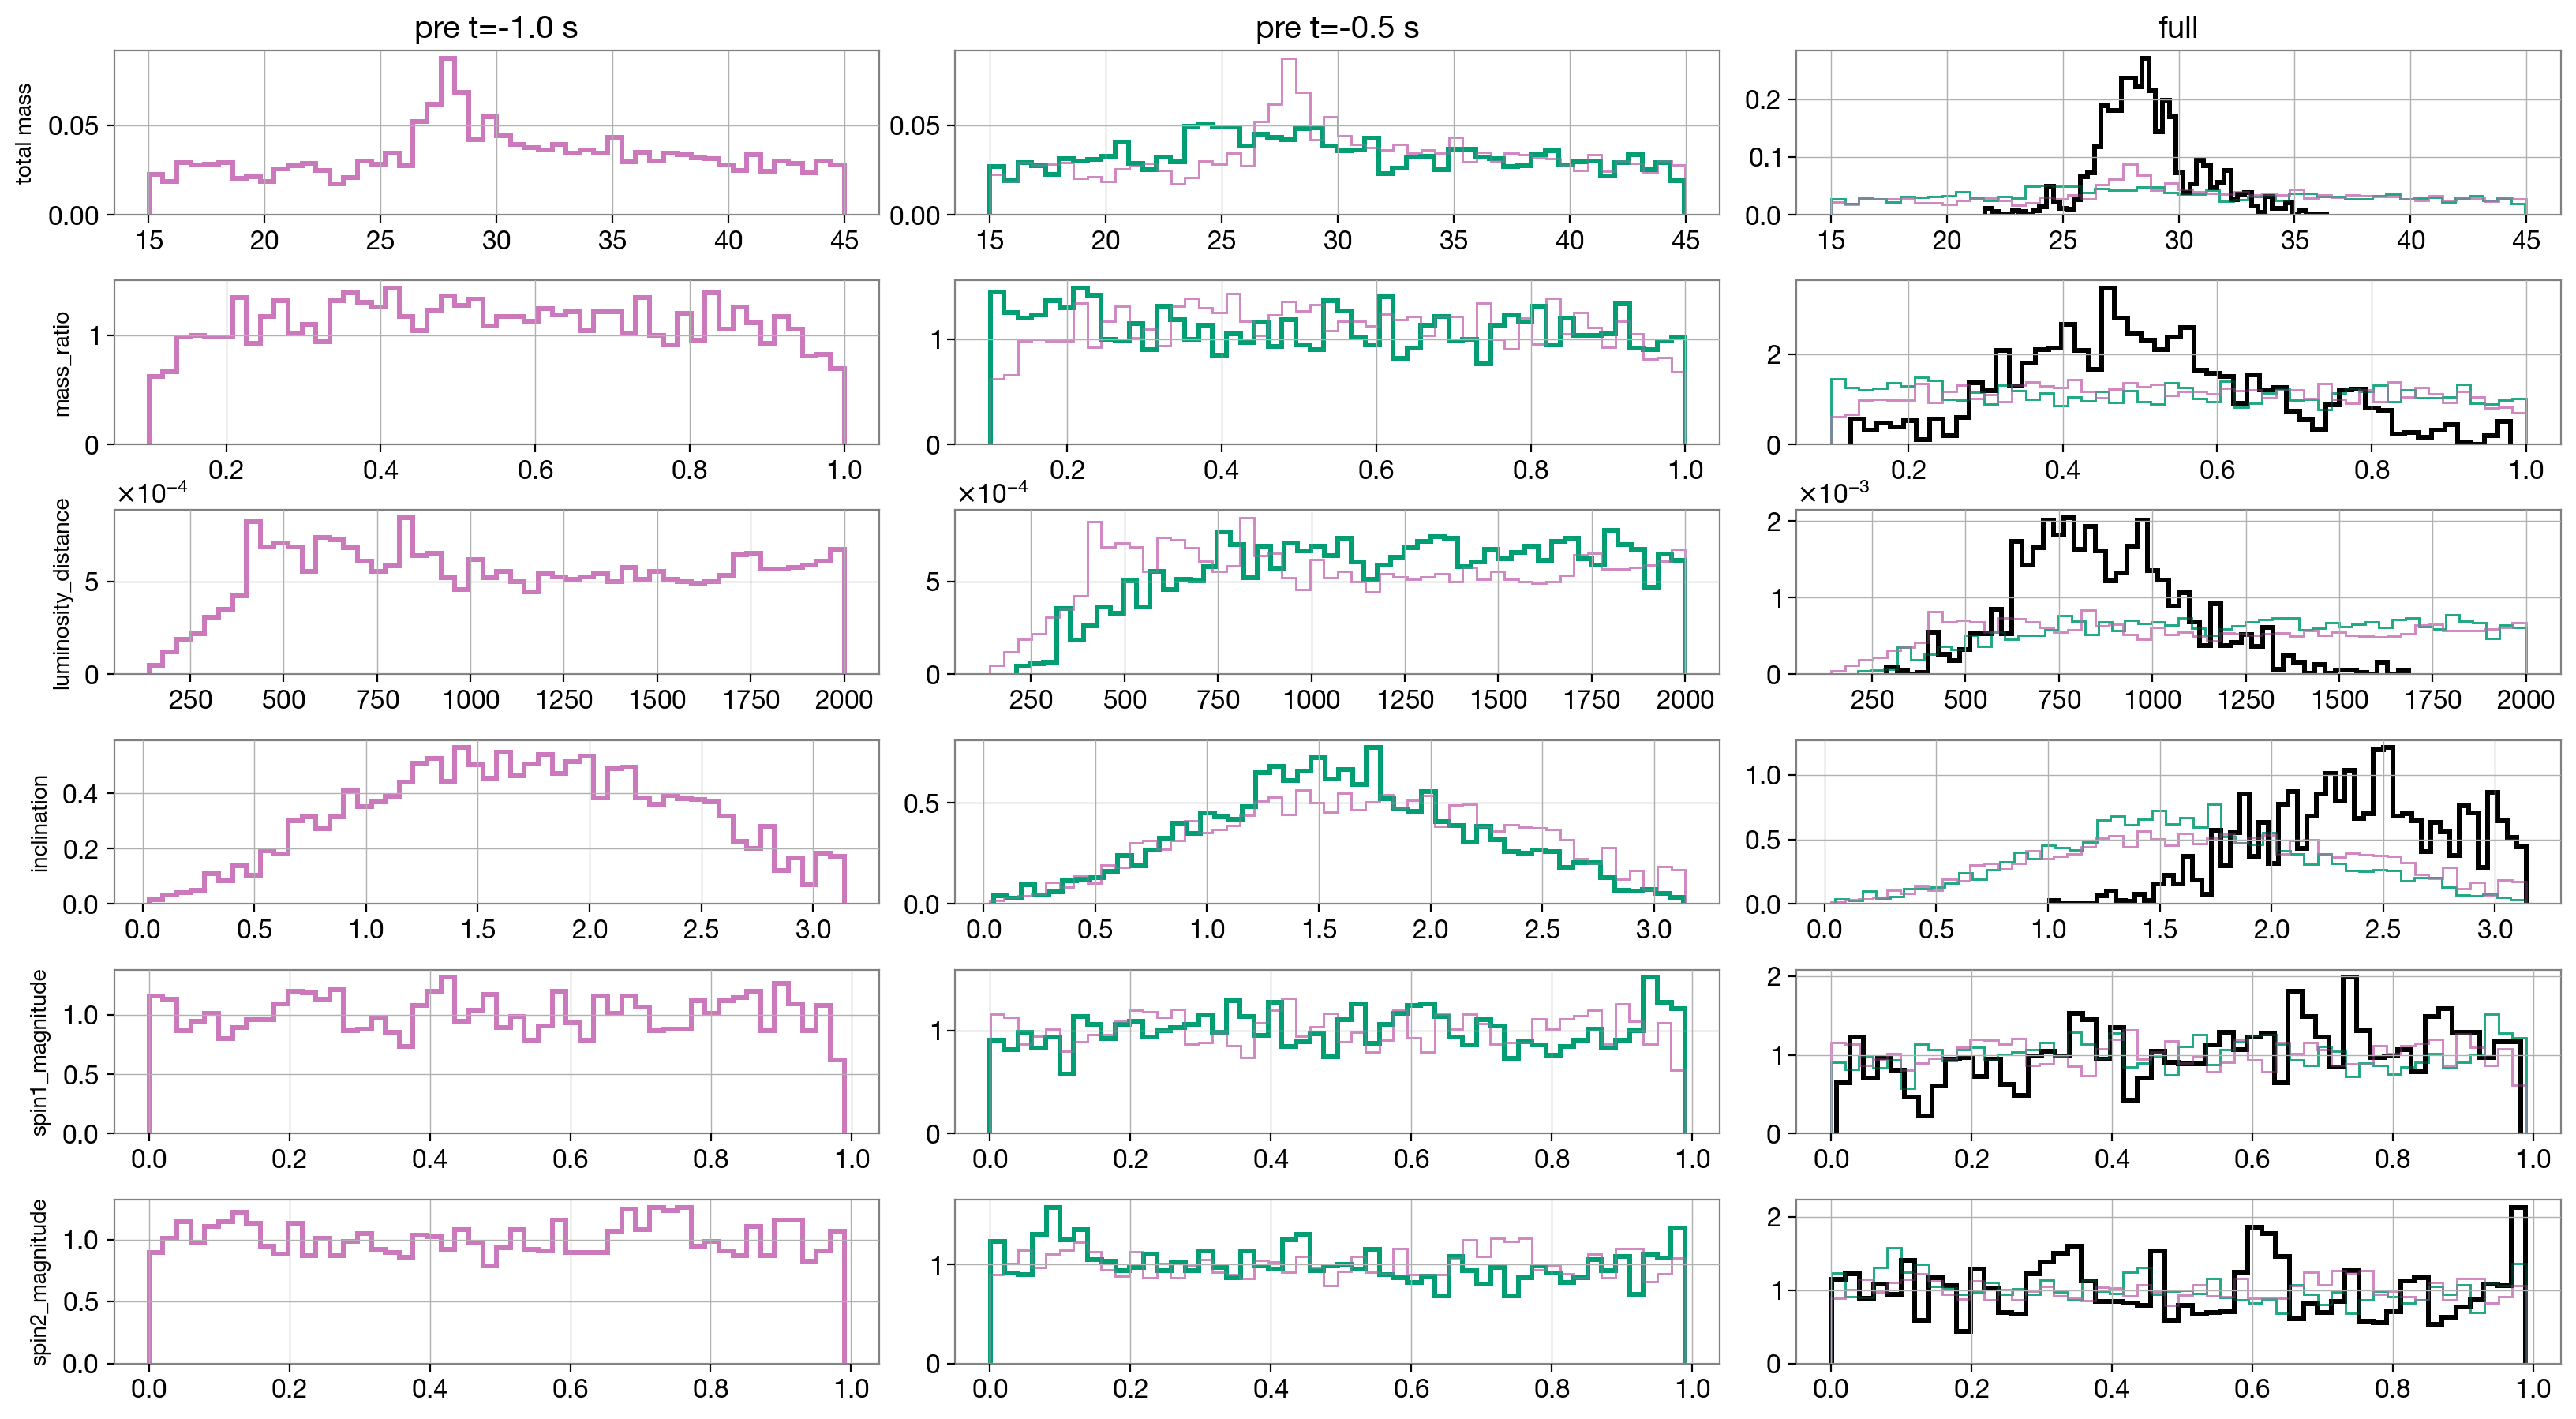

In [85]:
fig, axes = plt.subplots(6, 3, figsize=(20, 6 * 1.8))

for row, p in enumerate(params):
    # for col, (ds, color, label) in enumerate(zip(datasets, colors, labels)):
    #     ax = axes[row, col]
    #     ax.hist(result['dfs'][ds][p], density=True, histtype='step',
    #             bins=30, lw=2, color=color, label=label)
    #     ax.grid(color='silver', ls=':')

    axes[0,0].hist(result['dfs']['pre_-1.0']['total_mass'], density=True, histtype='step', bins=50, lw=2, color='C4', label='pre t=-1.0 s')
    axes[0,0].set_title('pre t=-1.0 s')
    axes[0,0].set_ylabel('total mass', fontsize=10)
    axes[0,1].hist(result['dfs']['pre_-0.5']['total_mass'], density=True, histtype='step', bins=50, lw=2, color='C2', label='pre t=-0.5 s')
    axes[0,1].hist(result['dfs']['pre_-1.0']['total_mass'], density=True, histtype='step', bins=50, lw=1, color='C4', alpha=0.3, label='full')
    axes[0,1].set_title('pre t=-0.5 s')
    axes[0,2].hist(result['dfs']['full']['total_mass'], density=True, histtype='step', bins=50, lw=2, color='k', label='full')
    axes[0,2].hist(result['dfs']['pre_-0.5']['total_mass'], density=True, histtype='step', bins=50, color='C2', alpha=0.3, label='pre t=-0.5 s')
    axes[0,2].hist(result['dfs']['pre_-1.0']['total_mass'], density=True, histtype='step', bins=50, color='C4', alpha=0.3, label='pre t=-1.0 s')
    axes[0,2].set_title('full')

    axes[1,0].hist(result['dfs']['pre_-1.0']['mass_ratio'], density=True, histtype='step', bins=50, lw=2, color='C4', label='pre t=-1.0 s')
    axes[1,0].set_ylabel('mass_ratio', fontsize=10)
    axes[1,1].hist(result['dfs']['pre_-0.5']['mass_ratio'], density=True, histtype='step', bins=50, lw=2, color='C2', label='pre t=-0.5 s')
    axes[1,1].hist(result['dfs']['pre_-1.0']['mass_ratio'], density=True, histtype='step', bins=50, lw=1, color='C4', alpha=0.3, label='full')
    axes[1,2].hist(result['dfs']['full']['mass_ratio'], density=True, histtype='step', bins=50, lw=2, color='k', label='full')
    axes[1,2].hist(result['dfs']['pre_-0.5']['mass_ratio'], density=True, histtype='step', bins=50, color='C2', alpha=0.3, label='pre t=-0.5 s')
    axes[1,2].hist(result['dfs']['pre_-1.0']['mass_ratio'], density=True, histtype='step', bins=50, color='C4', alpha=0.3, label='pre t=-1.0 s')

    axes[2,0].hist(result['dfs']['pre_-1.0']['luminosity_distance'], density=True, histtype='step', bins=50, lw=2, color='C4', label='pre t=-1.0 s')
    axes[2,0].set_ylabel('luminosity_distance', fontsize=10)
    axes[2,1].hist(result['dfs']['pre_-0.5']['luminosity_distance'], density=True, histtype='step', bins=50, lw=2, color='C2', label='pre t=-0.5 s')
    axes[2,1].hist(result['dfs']['pre_-1.0']['luminosity_distance'], density=True, histtype='step', bins=50, lw=1, color='C4', alpha=0.3, label='full')
    axes[2,2].hist(result['dfs']['full']['luminosity_distance'], density=True, histtype='step', bins=50, lw=2, color='k', label='full')
    axes[2,2].hist(result['dfs']['pre_-0.5']['luminosity_distance'], density=True, histtype='step', bins=50, color='C2', alpha=0.3, label='pre t=-0.5 s')
    axes[2,2].hist(result['dfs']['pre_-1.0']['luminosity_distance'], density=True, histtype='step', bins=50, color='C4', alpha=0.3, label='pre t=-1.0 s')

    axes[3,0].hist(result['dfs']['pre_-1.0']['inclination'], density=True, histtype='step', bins=50, lw=2, color='C4', label='pre t=-1.0 s')
    axes[3,0].set_ylabel('inclination', fontsize=10)
    axes[3,1].hist(result['dfs']['pre_-0.5']['inclination'], density=True, histtype='step', bins=50, lw=2, color='C2', label='pre t=-0.5 s')
    axes[3,1].hist(result['dfs']['pre_-1.0']['inclination'], density=True, histtype='step', bins=50, lw=1, color='C4', alpha=0.3, label='full')
    axes[3,2].hist(result['dfs']['full']['inclination'], density=True, histtype='step', bins=50, lw=2, color='k', label='full')
    axes[3,2].hist(result['dfs']['pre_-0.5']['inclination'], density=True, histtype='step', bins=50, color='C2', alpha=0.3, label='pre t=-0.5 s')
    axes[3,2].hist(result['dfs']['pre_-1.0']['inclination'], density=True, histtype='step', bins=50, color='C4', alpha=0.3, label='pre t=-1.0 s')

    axes[4,0].hist(result['dfs']['pre_-1.0']['spin1_magnitude'], density=True, histtype='step', bins=50, lw=2, color='C4', label='pre t=-1.0 s')
    axes[4,0].set_ylabel('spin1_magnitude', fontsize=10)
    axes[4,1].hist(result['dfs']['pre_-0.5']['spin1_magnitude'], density=True, histtype='step', bins=50, lw=2, color='C2', label='pre t=-0.5 s')
    axes[4,1].hist(result['dfs']['pre_-1.0']['spin1_magnitude'], density=True, histtype='step', bins=50, lw=1, color='C4', alpha=0.3, label='full')
    axes[4,2].hist(result['dfs']['full']['spin1_magnitude'], density=True, histtype='step', bins=50, lw=2, color='k', label='full')
    axes[4,2].hist(result['dfs']['pre_-0.5']['spin1_magnitude'], density=True, histtype='step', bins=50, color='C2', alpha=0.3, label='pre t=-0.5 s')
    axes[4,2].hist(result['dfs']['pre_-1.0']['spin1_magnitude'], density=True, histtype='step', bins=50, color='C4', alpha=0.3, label='pre t=-1.0 s')

    axes[5,0].hist(result['dfs']['pre_-1.0']['spin2_magnitude'], density=True, histtype='step', bins=50, lw=2, color='C4', label='pre t=-1.0 s')
    axes[5,0].set_ylabel('spin2_magnitude', fontsize=10)
    axes[5,1].hist(result['dfs']['pre_-0.5']['spin2_magnitude'], density=True, histtype='step', bins=50, lw=2, color='C2', label='pre t=-0.5 s')
    axes[5,1].hist(result['dfs']['pre_-1.0']['spin2_magnitude'], density=True, histtype='step', bins=50, lw=1, color='C4', alpha=0.3, label='full')
    axes[5,2].hist(result['dfs']['full']['spin2_magnitude'], density=True, histtype='step', bins=50, lw=2, color='k', label='full')
    axes[5,2].hist(result['dfs']['pre_-0.5']['spin2_magnitude'], density=True, histtype='step', bins=50, color='C2', alpha=0.3, label='pre t=-0.5 s')
    axes[5,2].hist(result['dfs']['pre_-1.0']['spin2_magnitude'], density=True, histtype='step', bins=50, color='C4', alpha=0.3, label='pre t=-1.0 s')

plt.subplots_adjust(hspace=0.4, wspace=0.1)
plt.show()

### If you have any further questions about running `tdinf` or plotting/interpreting results, reach out to `simona.miller@ligo.org`.